In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("C:/Users/ASUS/Desktop/FBS/Data science/Dataset/home_prices.csv")
data.head()

,area_sqr_ft,bedrooms,color,price_lakhs
0,3774,2,Red,216
1,1460,3,Gray,88
2,1894,4,Gray,147
3,1730,2,Blue,84
4,1695,1,Blue,77


In [3]:
data.describe()

,area_sqr_ft,bedrooms,price_lakhs
count,300.000000,300.000000,300.000000
mean,2371.990000,3.013333,148.050000
std,942.766953,1.446882,52.873113
min,601.000000,1.000000,15.000000
25%,1620.750000,2.000000,107.750000
50%,2342.500000,3.000000,151.000000
75%,3206.000000,4.000000,191.000000
max,3997.000000,5.000000,250.000000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   area_sqr_ft  300 non-null    int64 
 1   bedrooms     300 non-null    int64 
 2   color        300 non-null    object
 3   price_lakhs  300 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 9.5+ KB


In [5]:
data['color'].unique()

array(['Red', 'Gray', 'Blue', 'Yellow', 'Green', 'White'], dtype=object)

#### Data Encoding

In [6]:
data = pd.get_dummies(data,dtype ='int')
data.head()

,area_sqr_ft,bedrooms,price_lakhs,color_Blue,color_Gray,color_Green,color_Red,color_White,color_Yellow
0,3774,2,216,0,0,0,1,0,0
1,1460,3,88,0,1,0,0,0,0
2,1894,4,147,0,1,0,0,0,0
3,1730,2,84,1,0,0,0,0,0
4,1695,1,77,1,0,0,0,0,0


In [7]:
#1. encoded output will convert to dataframe
#2. concatenate original df and encoded df
#3. Drop original categorical column which is encoded 

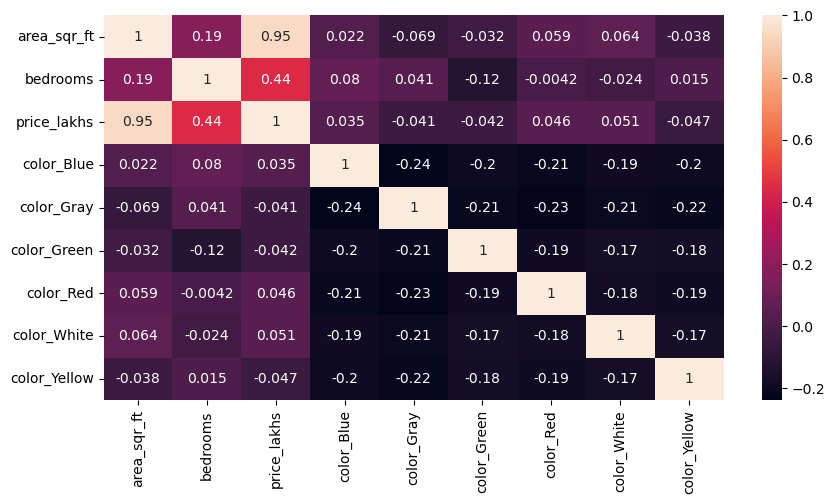

In [10]:
plt.figure(figsize = (10,5))
sns.heatmap(data.corr(),annot = True)
plt.show()

#### VIF

In [11]:
data = pd.read_csv("C:/Users/ASUS/Desktop/FBS/Data science/Dataset/salaries for VIF.csv")
data.head()

,Years of Experience,Education Level,Age,Location Factor,Salary
0,29,1,49,7,124204
1,27,3,45,4,125948
2,20,4,41,8,116078
3,14,4,37,5,106486
4,20,3,42,7,113297


In [12]:
X = data.drop('Salary',axis = 1)
y = data['Salary']

In [13]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Years of Experience  1000 non-null   int64
 1   Education Level      1000 non-null   int64
 2   Age                  1000 non-null   int64
 3   Location Factor      1000 non-null   int64
dtypes: int64(4)
memory usage: 31.4 KB


In [14]:
X.describe()

,Years of Experience,Education Level,Age,Location Factor
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,19.416000,2.449000,39.725000,5.448000
std,10.689397,1.118324,10.494928,2.912005
min,-11.000000,1.000000,6.000000,1.000000
25%,12.000000,1.000000,33.000000,3.000000
50%,19.000000,2.000000,40.000000,5.000000
75%,27.000000,3.000000,47.000000,8.000000
max,51.000000,4.000000,72.000000,10.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x201cb6060d0>,
 'caps': [<matplotlib.lines.Line2D at 0x201cb606350>,
 'boxes': [<matplotlib.lines.Line2D at 0x201cb605f90>],
 'medians': [<matplotlib.lines.Line2D at 0x201cb6065d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x201cb606710>],
 'means': []}

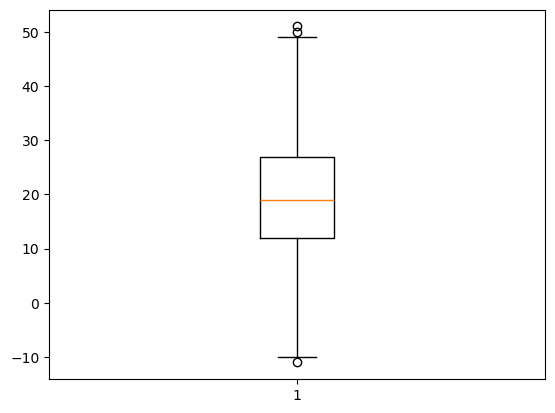

In [15]:
plt.boxplot(X['Years of Experience'])

In [16]:
##### Calculate vif
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [17]:
variance_inflation_factor(X,0)

np.float64(22.342087400051085)

In [18]:
variance_inflation_factor(X,2)

np.float64(42.20114897628524)

In [19]:
len(X)

1000

In [20]:
X.shape

(1000, 4)

In [24]:
result = pd.DataFrame()
result['Input Variables'] = X.columns
result

,Input Variables
0,Years of Experience
1,Education Level
2,Age
3,Location Factor


In [26]:
vif = []
for i in range(X.shape[1]):
    vif.append(variance_inflation_factor(X,i))
result['VIF'] = vif

In [27]:
result

,Input Variables,VIF
0,Years of Experience,22.342087
1,Education Level,5.472969
2,Age,42.201149
3,Location Factor,4.289467


In [28]:
X_new = X.drop(columns=['Age'])

In [29]:
result = pd.DataFrame()
result['Input Variables'] = X_new.columns
result

,Input Variables
0,Years of Experience
1,Education Level
2,Location Factor


In [30]:
vif = []
for i in range(X_new.shape[1]):
    vif.append(variance_inflation_factor(X_new,i))
result['VIF'] = vif
result

,Input Variables,VIF
0,Years of Experience,3.198601
1,Education Level,3.509425
2,Location Factor,3.231181
